### This notebook compute "P6. Susceptibility to landslides" indicator for the 27 basins of IKI Project

Spanish: Susceptibilidad a los movimientos en masa

**Created:** 10/2025 by Serena Gilson. Current contact: Sophia Bakar (sbakar@rti.org)

**Data:** Mapa de susceptibilidad por movimientos en masa regional (GEOCATMIN) https://geocatmin.ingemmet.gob.pe/geocatmin/

**N/A Handling:** There shouldn't be N/A values because all NA values are assigned a 1 according to the index rules.

This indicator is static

General Methodology:  
1. Determine the total susceptability pixels in each COMID.  
2. Calculate the percentage of pixels in each category within each COMID.  
3. Calculate the weighted score for each COMID, then round the values to force them to be 1, 2, 3, or 4, respectively indicating low, medium, high, or very high landslide susceptability.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterstats import zonal_stats
import rasterio
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
# set paths for input data and indicators database 
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
mapa_sus_land = master_path / "Indicadores" / "Datos_GEOCATMIN" / "su_mm_peru.tif"

In [4]:
IndID= 106 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

In [5]:
# read in subbasins shapefile 
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

In [6]:
# Check the range of values in the raster
with rasterio.open(mapa_sus_land) as src:
    raster_data = src.read(1)  # Read the first band
    
    # Get unique values and their counts
    unique_values, counts = np.unique(raster_data, return_counts=True)
    
    print("Unique values in mapa_sus_land:")
    for val, count in zip(unique_values, counts):
        print(f"  Value {val}: {count:,} pixels")
    
    print(f"\nMin value: {raster_data.min()}")
    print(f"Max value: {raster_data.max()}")
    
    # Check for NoData value
    print(f"NoData value: {src.nodata}")

Unique values in mapa_sus_land:
  Value 0: 40,720,938 pixels
  Value 1: 9,181,829 pixels
  Value 2: 5,738,694 pixels
  Value 3: 6,980,278 pixels
  Value 4: 5,397,338 pixels
  Value 5: 2,770,819 pixels

Min value: 0
Max value: 5
NoData value: 0.0


In [7]:
# Perform zonal statistics with categorical counts
stats = zonal_stats(
    subbasins_gdf,  # GeoDataFrame with geometries
    mapa_sus_land,   # Path to the raster file
    categorical=True,  # Get pixel counts for each category
    geojson_out=True  # Return GeoJSON-like output
)

# Calculate weighted susceptibility score for each COMID
weighted_scores = []

for feature in stats:
    comid = feature['properties']['COMID']
    pixel_counts = {k: v for k, v in feature['properties'].items() if isinstance(k, (int, float))}
    
    # Calculate total pixels
    total_pixels = sum(pixel_counts.values())
    
    if total_pixels == 0:
        weighted_scores.append({'COMID': comid, 'weighted_susceptibility': 1})
        continue
    
    # Calculate area percentages for each category #note differences than p7 due to 0-5 as opposed to 0-4
    # Category 1 or 2 = low or very low
    pct_1_or_2 = (pixel_counts.get(1, 0) + pixel_counts.get(2, 0)) / total_pixels
    # Category 3 = medium
    pct_2 = pixel_counts.get(3, 0) / total_pixels
    # Category 4 = high
    pct_3 = pixel_counts.get(4, 0) / total_pixels
    # Category 5 = very high
    pct_4 = pixel_counts.get(5, 0) / total_pixels

    # Calculate weighted score
    numerator = (pct_1_or_2 * 1) + (pct_2 * 2) + (pct_3 * 3) + (pct_4 * 4)
    denominator = pct_1_or_2 + pct_2 + pct_3 + pct_4
    if denominator > 0:
        weighted_score = numerator / denominator
        # Round to nearest integer and clip to 1-4 range
        weighted_score = np.clip(round(weighted_score), 1, 4)
    else:
        weighted_score = 1  # according to index null values should get a 1

    weighted_scores.append({'COMID': comid, 'weighted_susceptibility': weighted_score})

# Convert to DataFrame
weighted_scores_df = pd.DataFrame(weighted_scores)

# Merge with subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(weighted_scores_df, how="left", on="COMID")

<Axes: >

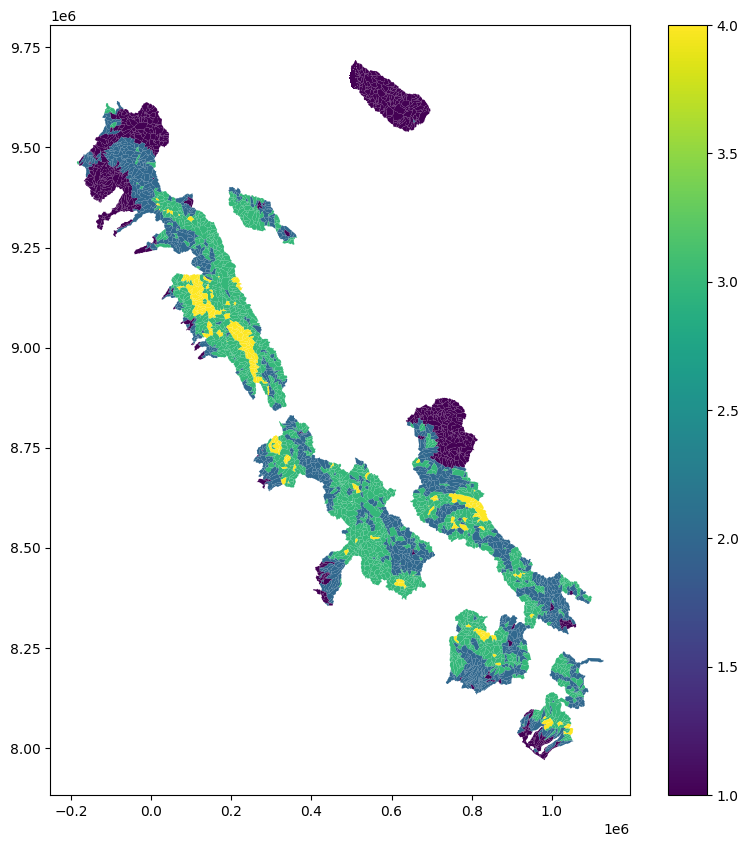

In [8]:
# Plot the weighted susceptibility values fpr QC
subbasins_gdf.plot(column="weighted_susceptibility", cmap="viridis", legend=True, figsize=(10, 10))

In [9]:
insert_data = subbasins_gdf
value_column = 'weighted_susceptibility'

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

insert_query = """
INSERT OR REPLACE INTO IndValues_Static(IndID, COMID, Value)
VALUES (?, ?, ?);
"""

rows_to_insert = []

for _, row in insert_data.iterrows():
    rows_to_insert.append((
        IndID,
        int(row['COMID']),
        int(row[value_column]) if not pd.isna(row[value_column]) else None
    ))


In [10]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['weighted_susceptibility']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 106  Min: 1, Max: 4

=== Values to be inserted (by scenario) ===
   index  weighted_susceptibility
0    min                        1
1    max                        4
2  count                     3655
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [IndID, COMID, Value]
Index: []


In [11]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()